# Land-Cover Classification in Richmond upon Thames, London (2020, 2022, 2024)

## Notebook 03 – Supervised Classification: Random Forest

This notebook applies a **supervised Random Forest classifier** to Sentinel-2 land-cover samples from Richmond upon Thames, London, using labelled training data prepared in **Notebook 01**.

The model uses spectral bands (**B2, B3, B4, B8**) and **NDVI** as input features to classify land-cover types into four major categories:

- **Water**
- **Vegetation**
- **Urban**
- **Bare soil / bright surface**

In addition to model training and performance evaluation, the trained classifier is applied to generate land-cover maps for **2020, 2022, and 2024**. The results are then used to analyse land-cover proportions and detect temporal changes across the study period.

Finally, the supervised Random Forest results are compared with the unsupervised **K-Means clustering** results from **Notebook 02** to assess differences in classification performance and change detection.

## 1. Setup

This section imports the libraries required for supervised machine learning, model evaluation and visualisation.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
start_time = time.time()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

np.random.seed(42)

print("Setup complete.")

Setup complete.


## 2. Load data

The yearly CSV files exported from Google Earth Engine are loaded and combined into one dataset.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Load yearly CSV files
df_2020 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2020_samples.csv")
df_2022 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2022_samples.csv")
df_2024 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2024_samples.csv")

# Add year column
df_2020["year"] = 2020
df_2022["year"] = 2022
df_2024["year"] = 2024

# Combine datasets
df = pd.concat([df_2020, df_2022, df_2024], ignore_index=True)

# Remove non-feature columns
df = df.drop(columns=["system:index", ".geo"], errors="ignore")

# Add class names
class_names = {
    1: "Water",
    2: "Vegetation",
    3: "Urban",
    4: "Bare soil / bright surface"
}

df["class_name"] = df["label"].map(class_names)

df.head()

,B2,B3,B4,B8,NDVI,label,year,class_name
0,255.0,311.0,218.0,251.0,0.070362,1,2020,Water
1,392.0,569.0,532.0,1490.0,0.473788,1,2020,Water
2,245.0,340.0,237.0,356.0,0.200675,1,2020,Water
3,262.0,320.0,199.0,183.0,-0.041885,1,2020,Water
4,288.0,412.0,295.0,370.0,0.112782,1,2020,Water


## 3. Check dataset

The combined dataset was checked to confirm the number of samples, available columns and class distribution before model training.

In [33]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nClass distribution:")
print(df["class_name"].value_counts())

Dataset shape: (9384, 8)

Columns:
Index(['B2', 'B3', 'B4', 'B8', 'NDVI', 'label', 'year', 'class_name'], dtype='object')

Class distribution:
class_name
Water                         3000
Vegetation                    3000
Urban                         3000
Bare soil / bright surface     384
Name: count, dtype: int64


## 4. Select features and labels

The Random Forest model uses Sentinel-2 spectral bands and NDVI as input features. The ESA WorldCover-derived land cover label is used as the target variable.

In [34]:
features = ["B2", "B3", "B4", "B8", "NDVI"]

X = df[features]
y = df["label"]

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (9384, 5)
Target vector: (9384,)


## 5. Split data into training and testing sets

The labelled dataset was split into training and testing sets. Stratified splitting was used to preserve the class distribution in both subsets.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts().sort_index())

print("\nTesting labels:")
print(y_test.value_counts().sort_index())

Training set: (7507, 5)
Testing set: (1877, 5)

Training labels:
label
1    2400
2    2400
3    2400
4     307
Name: count, dtype: int64

Testing labels:
label
1    600
2    600
3    600
4     77
Name: count, dtype: int64


## 6. Train Random Forest classifier

A Random Forest classifier was trained using Sentinel-2 spectral bands and NDVI to predict land cover classes.

In [36]:
# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


## 7. Evaluate model performance

The trained Random Forest classifier was evaluated using the testing dataset.

In [37]:
# Predict on testing set
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))

Accuracy: 0.871


In [38]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Water",
        "Vegetation",
        "Urban",
        "Bare soil / bright surface"
    ]
))

                            precision    recall  f1-score   support

                     Water       0.94      0.92      0.93       600
                Vegetation       0.86      0.85      0.86       600
                     Urban       0.83      0.86      0.84       600
Bare soil / bright surface       0.79      0.70      0.74        77

                  accuracy                           0.87      1877
                 macro avg       0.85      0.83      0.84      1877
              weighted avg       0.87      0.87      0.87      1877



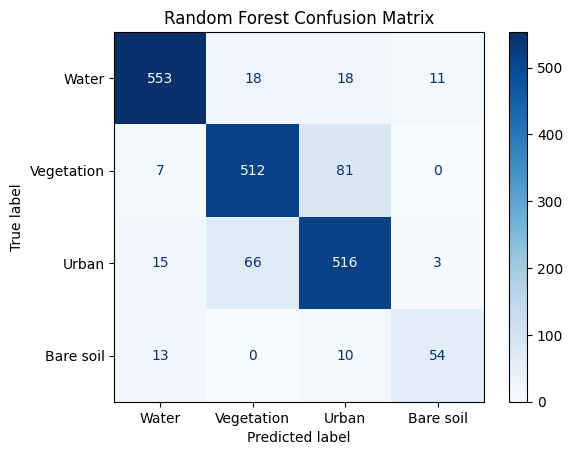

In [39]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Water",
        "Vegetation",
        "Urban",
        "Bare soil"
    ]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)

print("Cohen's Kappa:", round(kappa, 3))

Cohen's Kappa: 0.813


## 8. Feature importance

Feature importance was calculated to identify which Sentinel-2 bands and indices contributed most to the Random Forest classification.

In [41]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,B8,0.287322
4,NDVI,0.282599
0,B2,0.161404
1,B3,0.143672
2,B4,0.125003


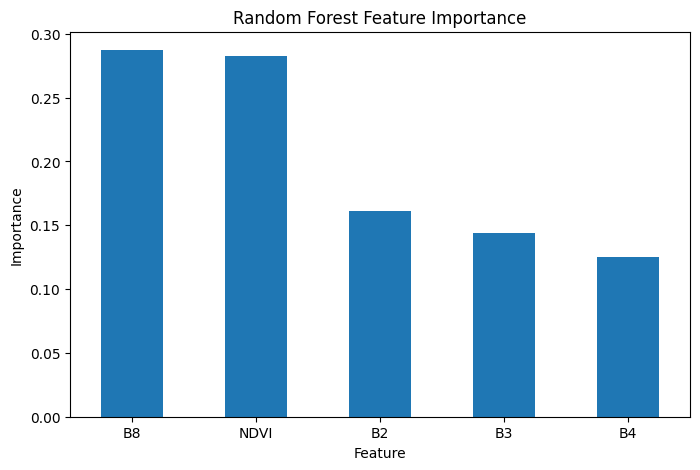

In [42]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()

## 9. Generate Random Forest classification maps

The trained Random Forest model was applied to the full Sentinel-2 feature rasters to produce supervised land cover classification maps for 2020, 2022 and 2024.

In [43]:
import rasterio
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


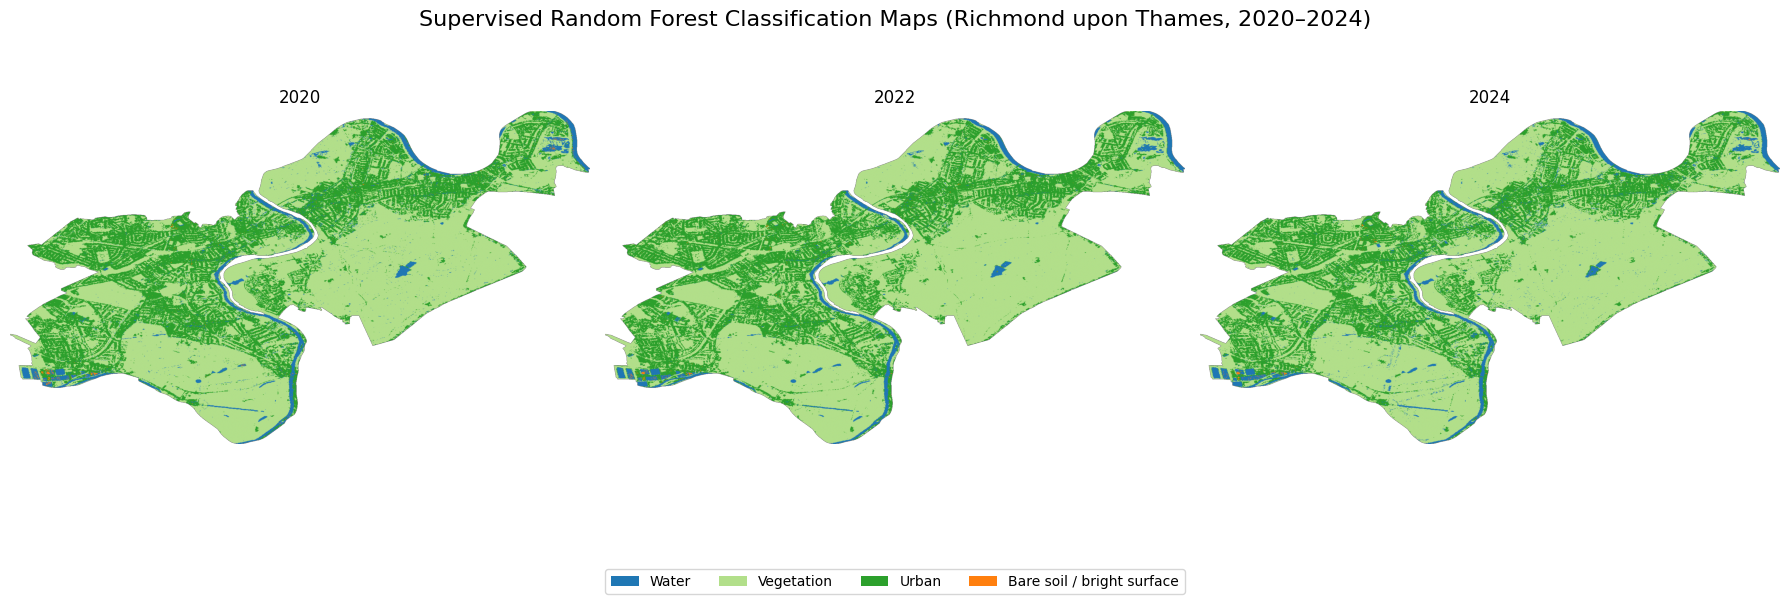

In [44]:
feature_files = {
    2020: "/content/drive/MyDrive/AI final project/richmond_features_2020.tif",
    2022: "/content/drive/MyDrive/AI final project/richmond_features_2022.tif",
    2024: "/content/drive/MyDrive/AI final project/richmond_features_2024.tif"
}

# Labels:
# 1 = Water
# 2 = Vegetation
# 3 = Urban
# 4 = Bare soil / bright surface
cmap = ListedColormap([
    "#1f77b4",  # Water
    "#b2df8a",  # Vegetation
    "#2ca02c",  # Urban
    "#ff7f0e"   # Bare soil / bright surface
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

classified_maps = {}

for ax, (year, path) in zip(axes, feature_files.items()):
    with rasterio.open(path) as src:
        img = src.read()
        img = np.moveaxis(img, 0, -1)

        rows, cols, bands = img.shape
        flat = img.reshape(-1, bands)

        valid_mask = np.all(np.isfinite(flat), axis=1)
        valid_mask &= np.any(flat != 0, axis=1)

        pred = np.full(flat.shape[0], np.nan)
        pred[valid_mask] = rf_model.predict(flat[valid_mask])

        classified = pred.reshape(rows, cols)
        classified_maps[year] = classified # Store the classified map for each year

        ax.imshow(classified, cmap=cmap, norm=norm)
        ax.set_title(str(year))
        ax.axis("off")

legend_elements = [
    Patch(facecolor="#1f77b4", label="Water"),
    Patch(facecolor="#b2df8a", label="Vegetation"),
    Patch(facecolor="#2ca02c", label="Urban"),
    Patch(facecolor="#ff7f0e", label="Bare soil / bright surface")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=4)

fig.suptitle(
    "Supervised Random Forest Classification Maps (Richmond upon Thames, 2020–2024)",
    fontsize=16
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## 10. Feature Importance Summary and Interpretation

Feature importance values were examined to identify which spectral bands and indices contributed most to the Random Forest classification.

In [45]:
import pandas as pd

# Create summary table
feature_summary = pd.DataFrame({
    'Feature': ['B2', 'B3', 'B4', 'B8', 'NDVI'],
    'Meaning': ['Blue', 'Green', 'Red', 'Near Infrared', 'Vegetation Index'],
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_summary = feature_summary.sort_values(
    by='Importance',
    ascending=False
).round(3)

feature_summary

,Feature,Meaning,Importance
3,B8,Near Infrared,0.287
4,NDVI,Vegetation Index,0.283
0,B2,Blue,0.161
1,B3,Green,0.144
2,B4,Red,0.125


## 11. Quantitative Comparison of Area Estimates (2020, 2022 and 2024)

This section compares estimated land-cover area proportions across 2020, 2022 and 2024 using the Random Forest classification results.

In [46]:
import pandas as pd
import numpy as np

# Class labels
class_names = {
    1: 'Water',
    2: 'Vegetation',
    3: 'Urban',
    4: 'Bare soil / bright surface'
}

# Calculate class percentages
def calculate_percentages(class_map):
    valid = class_map[~np.isnan(class_map)]
    total = len(valid)

    percentages = {}
    for cls in class_names.keys():
        count = np.sum(valid == cls)
        percentages[class_names[cls]] = (count / total) * 100

    return percentages

# Get percentages
area_2020 = calculate_percentages(classified_maps[2020])
area_2022 = calculate_percentages(classified_maps[2022])
area_2024 = calculate_percentages(classified_maps[2024])

area_df = pd.DataFrame({
    "2020 (%)": area_2020,
    "2022 (%)": area_2022,
    "2024 (%)": area_2024
})

area_df["Change 2020-2022 (%)"] = area_df["2022 (%)"] - area_df["2020 (%)"]
area_df["Change 2022-2024 (%)"] = area_df["2024 (%)"] - area_df["2022 (%)"]
area_df["Change 2020-2024 (%)"] = area_df["2024 (%)"] - area_df["2020 (%)"]

area_df = area_df.round(2)
area_df

,2020 (%),2022 (%),2024 (%),Change 2020-2022 (%),Change 2022-2024 (%),Change 2020-2024 (%)
Water,4.71,3.90,4.86,-0.81,0.96,0.16
Vegetation,61.29,63.09,64.28,1.79,1.20,2.99
Urban,33.81,32.86,30.72,-0.95,-2.13,-3.08
Bare soil / bright surface,0.19,0.16,0.13,-0.04,-0.03,-0.07


## 12. Visual Comparison of Area Changes

A bar chart was created to visualise the estimated land cover area proportions in 2020, 2022 and 2024.

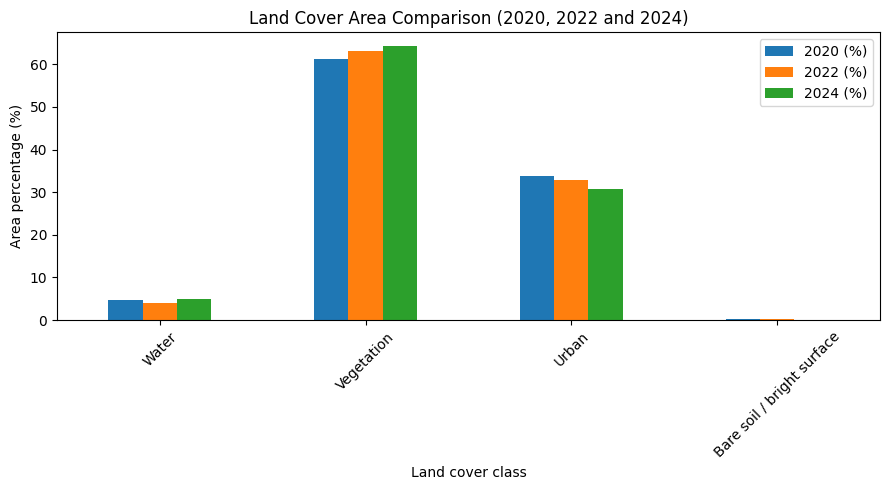

In [47]:
import matplotlib.pyplot as plt

# Plot comparison
area_df[["2020 (%)", "2022 (%)", "2024 (%)"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Land Cover Area Comparison (2020, 2022 and 2024)")
plt.ylabel("Area percentage (%)")
plt.xlabel("Land cover class")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Visual Change Maps Across Three Periods

This section highlights pixel-wise changes detected by the Random Forest classification for three transition periods: 2020–2022, 2022–2024 and 2020–2024.

The change maps show:

- urban gain
- vegetation loss

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Class labels
urban_class = 3
vegetation_class = 2

# Function to create change map
def create_change_map(map_start, map_end, urban_class, vegetation_class):
    change = np.zeros_like(map_start, dtype=np.uint8)

    # Urban gain
    change[
        (map_start != urban_class) &
        (map_end == urban_class)
    ] = 1

    # Vegetation loss (exclude urban gain)
    change[
        (map_start == vegetation_class) &
        (map_end != vegetation_class) &
        (map_end != urban_class)
    ] = 2

    # Mask invalid pixels
    change[np.isnan(map_start) | np.isnan(map_end)] = 0

    return change


# Generate RF change maps
rf_change_2020_2022 = create_change_map(
    classified_maps[2020],
    classified_maps[2022],
    urban_class,
    vegetation_class
)

rf_change_2022_2024 = create_change_map(
    classified_maps[2022],
    classified_maps[2024],
    urban_class,
    vegetation_class
)

rf_change_2020_2024 = create_change_map(
    classified_maps[2020],
    classified_maps[2024],
    urban_class,
    vegetation_class
)

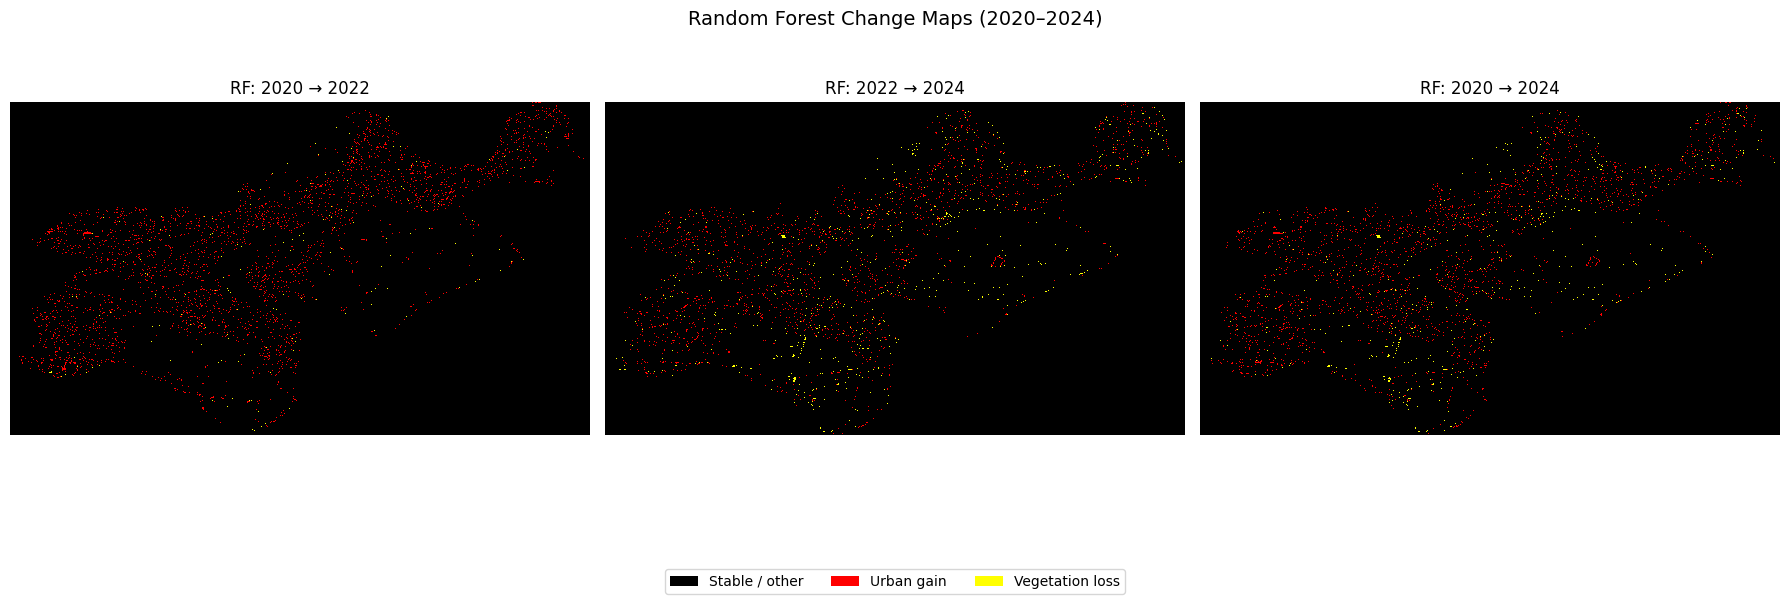

In [49]:
cmap_change = ListedColormap([
    "black",   # Stable / other
    "red",     # Urban gain
    "yellow"   # Vegetation loss
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_change.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

maps = [
    (rf_change_2020_2022, "RF: 2020 → 2022"),
    (rf_change_2022_2024, "RF: 2022 → 2024"),
    (rf_change_2020_2024, "RF: 2020 → 2024")
]

for ax, (m, title) in zip(axes, maps):
    ax.imshow(m, cmap=cmap_change, norm=norm, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

legend_elements = [
    Patch(facecolor="black", label="Stable / other"),
    Patch(facecolor="red", label="Urban gain"),
    Patch(facecolor="yellow", label="Vegetation loss")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=3)

fig.suptitle("Random Forest Change Maps (2020–2024)", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

The following K-Means comparison requires the K-Means maps generated in Notebook 2. If this notebook is run independently, the K-Means maps need to be regenerated or loaded before running this section.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


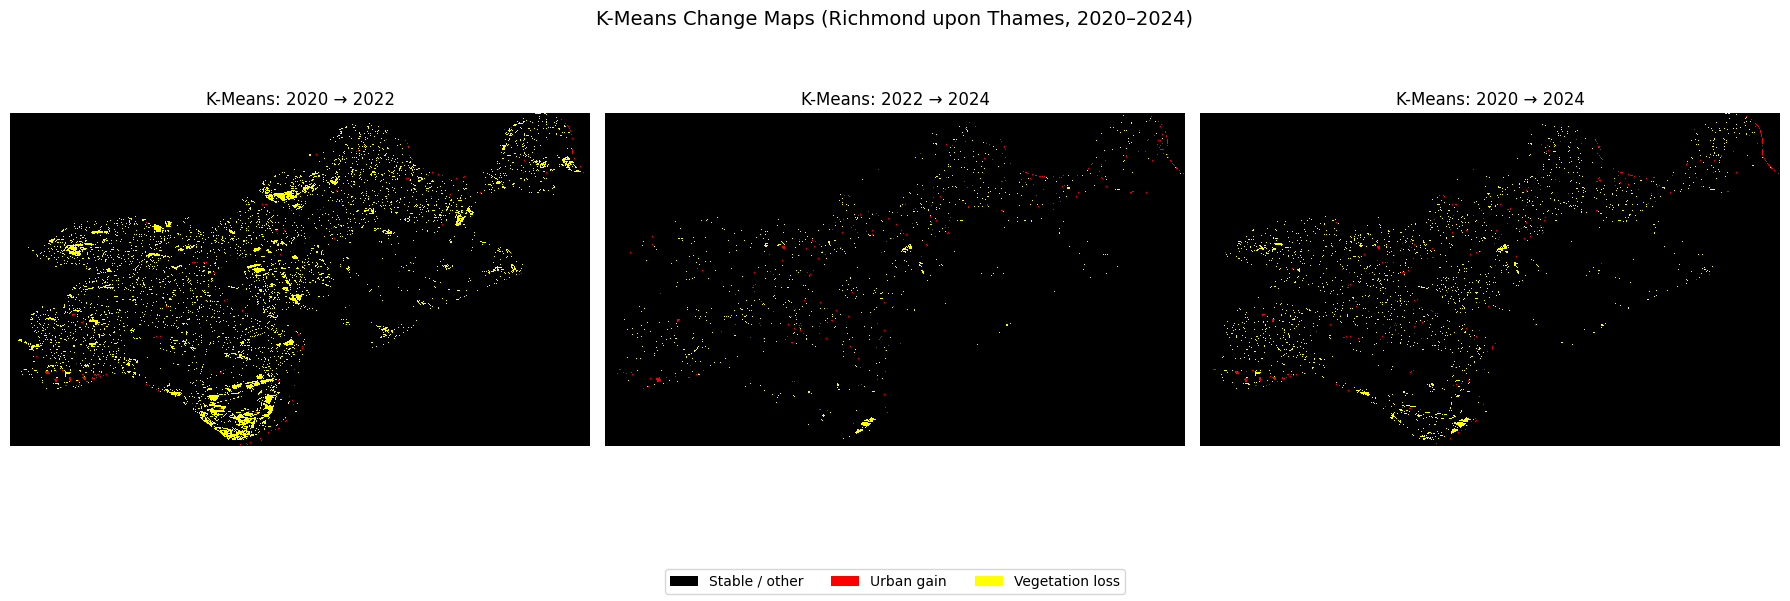

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import pandas as pd
import rasterio
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Re-generate KMeans classification maps (as the original cell was deleted)
# This code block was originally in cell 'ucS6go4JAygJ'

kmeans_maps = {}

# Define and fit StandardScaler and KMeans for comparison
# Using the full feature set X for unsupervised clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X is available from previous cells

# Initialize and fit KMeans with 4 clusters (matching land cover classes)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto') # n_init='auto' to suppress warning
kmeans.fit(X_scaled)

for year in [2020, 2022, 2024]:
    path = feature_files[year] # feature_files is available from previous cells

    with rasterio.open(path) as src:
        img = src.read()
        img = np.moveaxis(img, 0, -1)

        rows, cols, bands = img.shape
        flat = img.reshape(-1, bands)

        valid_mask = np.all(np.isfinite(flat), axis=1)
        valid_mask &= np.any(flat != 0, axis=1)

        pred = np.full(flat.shape[0], np.nan)

        flat_scaled = scaler.transform(flat[valid_mask].astype(np.float64))
        pred[valid_mask] = kmeans.predict(flat_scaled)

        kmeans_maps[year] = pred.reshape(rows, cols)

# Cluster meaning from KMeans:
# 0 = Urban
# 1 = Water
# 2 = Bare soil / bright surface
# 3 = Vegetation

urban_cluster = 0
vegetation_cluster = 3

# Function to create KMeans change map
def create_kmeans_change_map(map_start, map_end, urban_cluster, vegetation_cluster):
    change = np.zeros_like(map_start, dtype=np.uint8)

    # Urban gain
    change[
        (map_start != urban_cluster) &
        (map_end == urban_cluster)
    ] = 1

    # Vegetation loss, excluding vegetation to urban
    change[
        (map_start == vegetation_cluster) &
        (map_end != vegetation_cluster) &
        (map_end != urban_cluster)
    ] = 2

    # Mask invalid pixels
    change[np.isnan(map_start) | np.isnan(map_end)] = 0

    return change


# Generate KMeans change maps
kmeans_change_2020_2022 = create_kmeans_change_map(
    kmeans_maps[2020],
    kmeans_maps[2022],
    urban_cluster,
    vegetation_cluster
)

kmeans_change_2022_2024 = create_kmeans_change_map(
    kmeans_maps[2022],
    kmeans_maps[2024],
    urban_cluster,
    vegetation_cluster
)

kmeans_change_2020_2024 = create_kmeans_change_map(
    kmeans_maps[2020],
    kmeans_maps[2024],
    urban_cluster,
    vegetation_cluster
)


# Colourmap
cmap_change = ListedColormap(
    [
        "black",   # Stable / other
        "red",     # Urban gain
        "yellow"   # Vegetation loss
    ]
)

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_change.N)

# Plot KMeans change maps
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

maps = [
    (kmeans_change_2020_2022, "K-Means: 2020 → 2022"),
    (kmeans_change_2022_2024, "K-Means: 2022 → 2024"),
    (kmeans_change_2020_2024, "K-Means: 2020 → 2024")
]

for ax, (change_map_k, title) in zip(axes, maps):
    ax.imshow(
        change_map_k,
        cmap=cmap_change,
        norm=norm,
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.axis("off")

legend_elements = [
    Patch(facecolor="black", label="Stable / other"),
    Patch(facecolor="red", label="Urban gain"),
    Patch(facecolor="yellow", label="Vegetation loss")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=3)

fig.suptitle("K-Means Change Maps (Richmond upon Thames, 2020–2024)", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18, top=0.88)
plt.show()

## 14 Quantitative Change Summary

The number and percentage of changed pixels were calculated for each method across three transition periods: 2020–2022, 2022–2024 and 2020–2024.

In [51]:
import pandas as pd
import numpy as np

def change_summary(change_map, map_start, map_end, model_name, period):
    valid_pixels = np.sum(~np.isnan(map_start) & ~np.isnan(map_end))

    urban_gain = np.sum(change_map == 1)
    vegetation_loss = np.sum(change_map == 2)

    return {
        "Model": model_name,
        "Period": period,
        "Urban gain pixels": urban_gain,
        "Urban gain (%)": (urban_gain / valid_pixels) * 100,
        "Vegetation loss pixels": vegetation_loss,
        "Vegetation loss (%)": (vegetation_loss / valid_pixels) * 100
    }

change_summary_df = pd.DataFrame([
    change_summary(kmeans_change_2020_2022, kmeans_maps[2020], kmeans_maps[2022], "K-Means", "2020 → 2022"),
    change_summary(kmeans_change_2022_2024, kmeans_maps[2022], kmeans_maps[2024], "K-Means", "2022 → 2024"),
    change_summary(kmeans_change_2020_2024, kmeans_maps[2020], kmeans_maps[2024], "K-Means", "2020 → 2024"),

    change_summary(rf_change_2020_2022, classified_maps[2020], classified_maps[2022], "Random Forest", "2020 → 2022"),
    change_summary(rf_change_2022_2024, classified_maps[2022], classified_maps[2024], "Random Forest", "2022 → 2024"),
    change_summary(rf_change_2020_2024, classified_maps[2020], classified_maps[2024], "Random Forest", "2020 → 2024")
])

change_summary_df = change_summary_df.round(2)
change_summary_df

,Model,Period,Urban gain pixels,Urban gain (%),Vegetation loss pixels,Vegetation loss (%)
0,K-Means,2020 → 2022,2587,0.28,74956,8.11
1,K-Means,2022 → 2024,3692,0.40,9708,1.05
2,K-Means,2020 → 2024,4101,0.44,23738,2.57
3,Random Forest,2020 → 2022,32717,3.54,1597,0.17
4,Random Forest,2022 → 2024,20912,2.26,7051,0.76
5,Random Forest,2020 → 2024,24864,2.69,5341,0.58


## 15. Environmental Cost

In [52]:
# End timer and estimate environmental cost

end_time = time.time()
duration_sec = end_time - start_time
duration_hr = duration_sec / 3600

# Assumptions
CPU_POWER_W = 20                 # assumed CPU power in watts
CARBON_INTENSITY = 0.233         # kg CO2e per kWh, UK grid average
ELECTRICITY_COST = 0.30          # GBP per kWh

# Calculations
energy_kwh = (CPU_POWER_W / 1000) * duration_hr
co2_kg = energy_kwh * CARBON_INTENSITY
co2_g = co2_kg * 1000
cost_gbp = energy_kwh * ELECTRICITY_COST

print("Environmental cost estimate")
print("---------------------------")
print(f"Runtime: {duration_sec:.2f} seconds")
print(f"Runtime: {duration_hr:.4f} hours")
print(f"Energy used: {energy_kwh:.6f} kWh")
print(f"CO2 emitted: {co2_g:.3f} g CO2e")
print(f"Estimated electricity cost: £{cost_gbp:.4f}")

Environmental cost estimate
---------------------------
Runtime: 86.21 seconds
Runtime: 0.0239 hours
Energy used: 0.000479 kWh
CO2 emitted: 0.112 g CO2e
Estimated electricity cost: £0.0001


## 16. Conclusion

The Random Forest classifier achieved strong land-cover classification performance, with an overall **accuracy of 87.1%** and a **Cohen’s Kappa of 0.813**, indicating good agreement between predicted and reference labels.

Key findings:

- **Water** was classified most accurately, while **Vegetation** and **Urban** were also identified with good performance.
- **Bare soil / bright surfaces** remained the most difficult class due to their limited sample size and spectral similarity to other surfaces.
- **B8** and **NDVI** were the most important features, highlighting the importance of near-infrared and vegetation information for classification.

Temporal analysis showed an increase in **Vegetation** (+2.99%) and a decrease in **Urban** (-3.08%) between 2020 and 2024, while **Water** remained relatively stable.

Compared with K-Means clustering, the Random Forest model produced more reliable classification and change detection results, demonstrating the advantages of supervised learning for land-cover mapping.